In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

CONFIG = {
    'tickers': ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'META', 'TSLA', 'JPM', 'JNJ', 'KO'], 
    'data_dir': '../data',  # Relative path from src/backend/models/train/
    'seq_len': 60,          # Lookback window
    'pred_horizon': 5,      # Predict 5-day cumulative return
    'hidden_size': 32,
    'layers': 1,
    'dropout': 0.2,
    'batch_size': 64,
    'learning_rate': 0.001,
    'epochs': 20,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

torch.manual_seed(42)
np.random.seed(42)

# Verify data path
data_path = Path(CONFIG['data_dir']).resolve()
print(f"Running on {CONFIG['device']}")
print(f"Data Directory resolved to: {data_path}")
if not data_path.exists():
    print("WARNING: Data directory does not exist! Check your path.")

Running on cpu
Data Directory resolved to: /Users/macbook/Downloads/HCMUT/Assignments/AI Projects/trend-spy-bot/src/backend/models/data


In [ ]:
def load_local_data(tickers, data_dir):
    print(f"Loading {len(tickers)} tickers from local storage...")
    data = {}
    path = Path(data_dir)
    
    for ticker in tickers:
        file_path = path / f"{ticker}.csv"
        
        if file_path.exists():
            try:
                df = pd.read_csv(file_path)
                
                # Clean up columns and ensure proper Date parsing
                df.columns = df.columns.str.strip().str.title()
                
                if 'Date' in df.columns:
                    df['Date'] = pd.to_datetime(df['Date'])
                    df = df.sort_values('Date').set_index('Date')
                
                required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
                if all(col in df.columns for col in required_cols):
                    data[ticker] = df
                    print(f"  {ticker}: {len(df)} rows loaded")
                else:
                    print(f"  ⚠️ {ticker}: Missing required columns. Found: {df.columns.tolist()}")
                    
            except Exception as e:
                print(f"  ❌ Error reading {ticker}: {e}")
        else:
            print(f"  ⚠️ File not found: {file_path}")
            
    return data

raw_data = load_local_data(CONFIG['tickers'], CONFIG['data_dir'])

if len(raw_data) == 0:
    raise ValueError("No data loaded. Please check your data directory and file names.")

Loading 10 tickers from local storage...
  AAPL: 11332 rows loaded
  MSFT: 10006 rows loaded
  NVDA: 6755 rows loaded
  AMZN: 7180 rows loaded
  GOOGL: 5354 rows loaded
  META: 3402 rows loaded
  TSLA: 3879 rows loaded
  JPM: 10561 rows loaded
  JNJ: 14098 rows loaded
  KO: 14098 rows loaded


In [ ]:
def engineer_features(df):
    df = df.copy()
    
    # Log Returns (velocity), scaled up for numerical stability
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
    
    # 5-day forward cumulative log return (the prediction target)
    df['Target_5D'] = df['Log_Ret'].rolling(window=5).sum().shift(-5)
    
    # Momentum: Rate of Change over several lookbacks
    for p in [5, 10, 20]:
        df[f'ROC_{p}'] = df['Close'].pct_change(p) * 100

    # 20-day rolling volatility (std of returns)
    df['Vol_20'] = df['Log_Ret'].rolling(20).std()
    
    # Volume ratio (relative to trailing 20-day mean volume)
    df['Vol_Ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
    
    # RSI (14-day)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).ewm(span=14, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(span=14, adjust=False).mean()
    rs = gain / loss.replace(0, 1e-9)
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'] / 100.0  # 0-1 scaling for neural net

    return df.dropna()

processed_data = {}
for ticker, df in raw_data.items():
    processed_data[ticker] = engineer_features(df)

print(f"Processed {len(processed_data)} tickers. Example features:\n")
print(processed_data['AAPL'][['Log_Ret', 'Target_5D', 'RSI', 'Vol_20']].head())

Processed 10 tickers. Example features:

             Log_Ret  Target_5D       RSI    Vol_20
Date                                               
1981-01-13 -3.621891   4.409247  0.413465  4.504795
1981-01-14  0.408972   5.941962  0.424563  4.303963
1981-01-15  2.020146   5.068985  0.481196  3.852667
1981-01-16 -0.803172   5.491221  0.460288  3.859932
1981-01-19  5.872158  -1.919333  0.607770  3.996678


In [ ]:
train_dfs = []
test_dfs = []

split_date = '2020-01-01'
resume_date = '2021-01-01'

for ticker, df in processed_data.items():
    train = df[df.index < split_date].copy()
    test = df[df.index >= resume_date].copy()
    train['Ticker'] = ticker
    test['Ticker'] = ticker
    train_dfs.append(train)
    test_dfs.append(test)

# Combine before scaling
full_train = pd.concat(train_dfs)
full_test = pd.concat(test_dfs)

# Exclude target, ticker, and OHLC columns from input features
feature_cols = [c for c in full_train.columns if c not in ['Target_5D', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']]
print(f"Features ({len(feature_cols)}): {feature_cols}")

# Fit scaler on training set only (prevents leakage)
scaler = StandardScaler()
full_train[feature_cols] = scaler.fit_transform(full_train[feature_cols])
full_test[feature_cols] = scaler.transform(full_test[feature_cols])

print(f"Train Rows: {len(full_train)}, Test Rows: {len(full_test)}")

Features (7): ['Log_Ret', 'ROC_5', 'ROC_10', 'ROC_20', 'Vol_20', 'Vol_Ratio', 'RSI']
Train Rows: 71615, Test Rows: 12270


In [ ]:
class BaselineDataset(Dataset):
    def __init__(self, df, seq_len, features, target_col='Target_5D'):
        self.data = df
        self.seq_len = seq_len
        self.features = features
        self.target_col = target_col

        # Avoid windowing across different stocks
        self.sequences = []
        for ticker in df['Ticker'].unique():
            ticker_df = df[df['Ticker'] == ticker]
            data_values = ticker_df[features].values
            target_values = ticker_df[target_col].values

            for i in range(len(ticker_df) - seq_len):
                x = data_values[i : i+seq_len]
                y = target_values[i+seq_len-1]  # Target at end of sequence
                self.sequences.append((x, y))
                
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x, y = self.sequences[idx]
        return torch.FloatTensor(x), torch.FloatTensor([y])

train_ds = BaselineDataset(full_train, CONFIG['seq_len'], feature_cols)
test_ds = BaselineDataset(full_test, CONFIG['seq_len'], feature_cols)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False)

print(f"Train Batches: {len(train_loader)}")

Train Batches: 1110


In [ ]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super(BaselineLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_dim, 
            hidden_dim, 
            num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        self.head = nn.Linear(hidden_dim, 1)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        # Take last time step
        last_step = out[:, -1, :]
        return self.head(last_step)

model = BaselineLSTM(
    len(feature_cols), 
    CONFIG['hidden_size'], 
    CONFIG['layers'], 
    CONFIG['dropout']
).to(CONFIG['device'])

optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])
criterion = nn.MSELoss()

/Users/macbook/.pyenv/versions/3.11.7/lib/python3.11/site-packages/torch/nn/modules/rnn.py:83: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "
/Users/macbook/.pyenv/versions/3.11.7/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
class UniversalDataProcessor:
    def __init__(self, data_dir, tickers):
        self.data_dir = Path(data_dir)
        self.tickers = sorted(tickers)  # sort so index 0 is always same stock
        self.stock_to_id = {ticker: i for i, ticker in enumerate(self.tickers)}
        
    def load_and_process(self):
        print("Loading and aligning data...")
        dfs = []
        
        for ticker in self.tickers:
            fpath = self.data_dir / f"{ticker}.csv"
            if fpath.exists():
                df = pd.read_csv(fpath)
                df.columns = df.columns.str.strip().str.title()
                df['Date'] = pd.to_datetime(df['Date'])
                df = df.set_index('Date').sort_index()
                df = self._engineer_features(df)
                df['Ticker'] = ticker
                df['Stock_ID'] = self.stock_to_id[ticker]
                dfs.append(df)
            else:
                print(f"Warning: {ticker} not found.")

        # Only keep dates where ALL stocks have data (fixed universe)
        common_index = dfs[0].index
        for df in dfs[1:]:
            common_index = common_index.intersection(df.index)
        
        print(f"Fixed Universe: {len(self.tickers)} stocks, {len(common_index)} common days.")
        
        aligned_dfs = []
        for df in dfs:
            aligned_dfs.append(df.loc[common_index])
            
        universal_df = pd.concat(aligned_dfs).reset_index()
        
        feature_cols = [c for c in universal_df.columns if c not in ['Date', 'Ticker', 'Stock_ID', 'Target_5D', 'Log_Ret_Raw']]
        
        print("Applying Cross-Sectional Z-Scores...")
        universal_df[feature_cols] = universal_df.groupby('Date')[feature_cols].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-8)
        )
        universal_df[feature_cols] = universal_df[feature_cols].clip(-3, 3)
        
        self.feature_cols = feature_cols
        return universal_df

    def _engineer_features(self, df):
        df = df.copy()
        df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1)) * 100
        df['Log_Ret_Raw'] = df['Log_Ret']
        df['Target_5D'] = df['Log_Ret_Raw'].rolling(5).sum().shift(-5)
        for p in [20, 60]:
            sma = df['Close'].rolling(p).mean()
            df[f'Dist_SMA_{p}'] = (df['Close'] / sma) - 1
        df['Vol_20'] = df['Log_Ret'].rolling(20).std()
        delta = df['Close'].diff()
        gain = (delta.where(delta > 0, 0)).ewm(span=14).mean()
        loss = (-delta.where(delta < 0, 0)).ewm(span=14).mean()
        rs = gain / loss.replace(0, 1e-9)
        df['RSI'] = 100 - (100 / (1 + rs))
        df['RSI'] = df['RSI'] / 100.0  # scale 0-1
        return df.dropna()

processor = UniversalDataProcessor(CONFIG['data_dir'], CONFIG['tickers'])
universal_df = processor.load_and_process()

Loading and aligning data...
Fixed Universe: 10 stocks, 3338 common days.
Applying Cross-Sectional Z-Scores...


Starting Training...
Epoch 5 | Train Loss: 27.7440 | Test Loss: 25.4820
Epoch 10 | Train Loss: 26.1056 | Test Loss: 26.1669
Epoch 15 | Train Loss: 24.7712 | Test Loss: 28.7754
Epoch 20 | Train Loss: 23.5725 | Test Loss: 29.7639


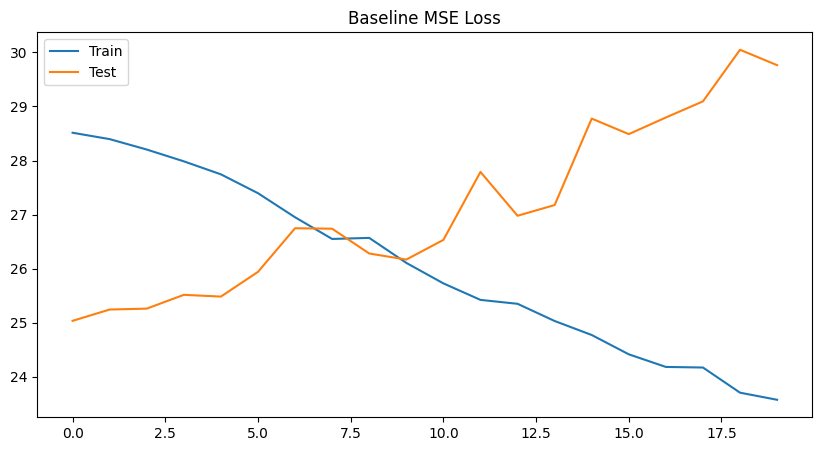

In [ ]:
history = {'train_loss': [], 'test_loss': []}

print("Starting Training...")
for epoch in range(CONFIG['epochs']):
    model.train()
    train_loss = 0
    
    for x, y in train_loader:
        x, y = x.to(CONFIG['device']), y.to(CONFIG['device'])
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    train_loss /= len(train_loader)
    
    # Evaluate on test set
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(CONFIG['device']), y.to(CONFIG['device'])
            pred = model(x)
            test_loss += criterion(pred, y).item()
            
    test_loss /= len(test_loader)
    
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Train')
plt.plot(history['test_loss'], label='Test')
plt.title("Baseline MSE Loss")
plt.legend()
plt.show()

--- Baseline Results ---
MAE: 3.7026 (Avg error in % return)
IC (Spearman): 0.0283 (Target > 0.01)
Directional Acc: 53.76%


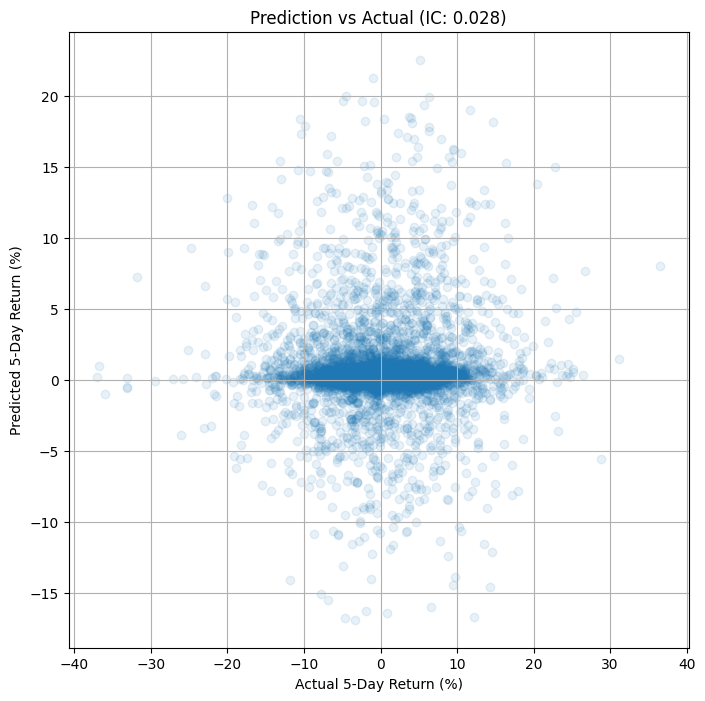

In [ ]:
model.eval()
preds = []
actuals = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(CONFIG['device'])
        output = model(x).cpu().numpy()
        target = y.numpy()
        preds.extend(output.flatten())
        actuals.extend(target.flatten())

preds = np.array(preds)
actuals = np.array(actuals)

mae = np.mean(np.abs(preds - actuals))
ic, p_val = spearmanr(preds, actuals)
direction_acc = np.mean((preds > 0) == (actuals > 0))

print(f"--- Baseline Results ---")
print(f"MAE: {mae:.4f} (Avg error in % return)")
print(f"IC (Spearman): {ic:.4f} (Target > 0.01)")
print(f"Directional Acc: {direction_acc*100:.2f}%")

plt.figure(figsize=(8, 8))
plt.scatter(actuals, preds, alpha=0.1)
plt.xlabel("Actual 5-Day Return (%)")
plt.ylabel("Predicted 5-Day Return (%)")
plt.title(f"Prediction vs Actual (IC: {ic:.3f})")
plt.grid(True)
plt.show()

In [ ]:
from scipy.stats import spearmanr
import numpy as np

# IC p-value (statistical significance)
ic, p_val = spearmanr(preds, actuals)
print(f"IC p-value: {p_val:.4f} (If <0.05, significant)")

# Simple Long-Only Backtest Return
strategy_returns = actuals[preds > 0]  # Only take actual returns where pred positive
if len(strategy_returns) > 0:
    avg_strategy_ret = np.mean(strategy_returns)
    total_strategy_ret = np.prod(1 + strategy_returns / 100) - 1  # Compound
    print(f"Avg Strategy Return per Trade: {avg_strategy_ret:.2f}%")
    print(f"Total Compounded Strategy Return: {total_strategy_ret * 100:.2f}%")
else:
    print("No positive predictions—model too conservative")

# Number of Test Predictions
print(f"Number of Test Predictions: {len(preds)}")

IC p-value: 0.0022 (If <0.05, significant)
Avg Strategy Return per Trade: 0.39%
Total Compounded Strategy Return: 7107636428700.00%
Number of Test Predictions: 11670
